# Data Visualisation: Urban Traffic Dataset

This notebook explores the **cleaned** dataset (`urban_traffic_cleaned.csv`, produced by the data-cleaning notebook) with 12 charts. Each chart comes with a short reading of what it shows.

| # | Chart | Question it answers |
|---|---|---|
| 1 | Congestion class balance | Is the target balanced? |
| 2 | Hourly profile | When is traffic heavy, weekday vs weekend? |
| 3 | Utilisation heatmap | Which day/hour combinations are busiest? |
| 4 | One-week time series | What does the raw signal look like? |
| 5 | Speed vs load | How does speed collapse near capacity? |
| 6 | Rain effect | Does weather slow traffic? |
| 7 | Incident impact | How costly is an incident? |
| 8 | Stadium events | Do events change evening traffic? |
| 9 | Correlations | Which features relate to each other? |
| 10 | Autocorrelation | How predictable is the past → future? |
| 11 | Congestion by hour | When does congestion occur? |
| 12 | Daily totals | Weekly cycle and trend |

Place `urban_traffic_cleaned.csv` next to this notebook and run all cells.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

INPUT = "urban_traffic_cleaned.csv"

DAY_NAMES = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
LEVELS = ["Low", "Moderate", "High", "Severe"]
LEVEL_COLORS = {"Low": "#4CAF50", "Moderate": "#FFC107", "High": "#FF7043", "Severe": "#C62828"}
SITE_COLORS = {"CBD": "#1f77b4", "Arterial": "#d62728", "Residential": "#2ca02c", "Stadium": "#9467bd"}
SITES = list(SITE_COLORS)
plt.rcParams.update({
    "figure.dpi": 100, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.labelsize": 10, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3,
})

## Load data

In [2]:
def load_data(path):
    df = pd.read_csv(path, parse_dates=["timestamp"])
    df["site"] = df["intersection_id"].str[7:]                     # CBD, Arterial, ...
    df["utilisation"] = df["vehicle_count"] / df["road_capacity_veh_15min"]
    df["date"] = df["timestamp"].dt.date
    return df

df = load_data(INPUT)
print(f"{len(df):,} rows | {df['site'].nunique()} intersections | "
      f"{df['timestamp'].min():%Y-%m-%d} to {df['timestamp'].max():%Y-%m-%d}")
df.head()

69,120 rows | 4 intersections | 2025-01-06 to 2025-07-04


,timestamp,intersection_id,hour,minute,day_of_week,is_weekend,is_holiday,event_nearby,temperature_c,rain_mm_15min,...,prev_count_1h,count_same_time_yesterday,count_same_time_last_week,rolling_mean_1h,target_next_count,target_congestion,n_imputed_sensor_values,site,utilisation,date
0,2025-01-06 00:00:00,INT_01_CBD,0,0,0,0,0,0,2.6,0.0,...,NaN,NaN,NaN,NaN,36.0,Low,0,CBD,0.054762,2025-01-06
1,2025-01-06 00:15:00,INT_01_CBD,0,15,0,0,0,0,2.7,0.0,...,NaN,NaN,NaN,NaN,28.0,Low,0,CBD,0.085714,2025-01-06
2,2025-01-06 00:30:00,INT_01_CBD,0,30,0,0,0,0,2.4,0.0,...,NaN,NaN,NaN,NaN,33.0,Low,0,CBD,0.066667,2025-01-06
3,2025-01-06 00:45:00,INT_01_CBD,0,45,0,0,0,0,1.5,0.0,...,NaN,NaN,NaN,NaN,19.0,Low,0,CBD,0.078571,2025-01-06
4,2025-01-06 01:00:00,INT_01_CBD,1,0,0,0,0,0,3.1,0.0,...,23.0,NaN,NaN,30.0,32.0,Low,0,CBD,0.045238,2025-01-06


## 1. Congestion class balance

**What it shows:** about 62% of intervals are *Low*, 23% *Moderate*, 7% *High* and 8% *Severe*. The classes are **imbalanced**, so plain accuracy is misleading. Use macro-F1 or class weights when modelling.

The intersections also differ a lot: the **Arterial** is the most congested (about 17% Severe), while the **Residential** street is Low about 79% of the time and almost never Severe.

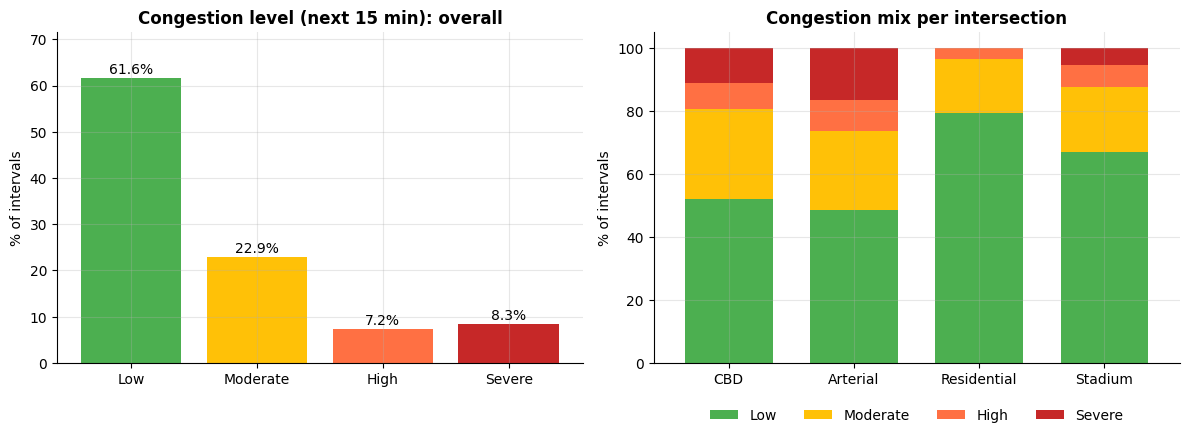

In [3]:
def plot_congestion_distribution(df):
    d = df.dropna(subset=["target_congestion"])
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
    share = d["target_congestion"].value_counts(normalize=True).reindex(LEVELS) * 100
    bars = ax[0].bar(LEVELS, share.values, color=[LEVEL_COLORS[l] for l in LEVELS])
    for b, v in zip(bars, share.values):
        ax[0].text(b.get_x() + b.get_width() / 2, v + 1, f"{v:.1f}%", ha="center", fontsize=10)
    ax[0].set_title("Congestion level (next 15 min): overall")
    ax[0].set_ylabel("% of intervals"); ax[0].set_ylim(0, share.max() + 10)

    ct = pd.crosstab(d["site"], d["target_congestion"], normalize="index").reindex(SITES)[LEVELS] * 100
    ct.plot(kind="bar", stacked=True, ax=ax[1], color=[LEVEL_COLORS[l] for l in LEVELS], width=0.7)
    ax[1].set_title("Congestion mix per intersection"); ax[1].set_ylabel("% of intervals")
    ax[1].set_xlabel(""); ax[1].tick_params(axis="x", rotation=0); ax[1].legend(title="", ncol=4, loc="upper center",
                                                                              bbox_to_anchor=(0.5, -0.1), frameon=False)
    fig.tight_layout()
    return fig

plot_congestion_distribution(df)
plt.show()

## 2. Hourly traffic profile: weekday vs weekend

**What it shows:** weekdays have two clear **rush-hour peaks** (about 8 AM and 5 PM) with a lull in between. Weekends have a single, flatter **midday hump** around noon. Nights are quiet everywhere.

The Arterial carries the most traffic and the Residential street the least, but all four share the same shape.

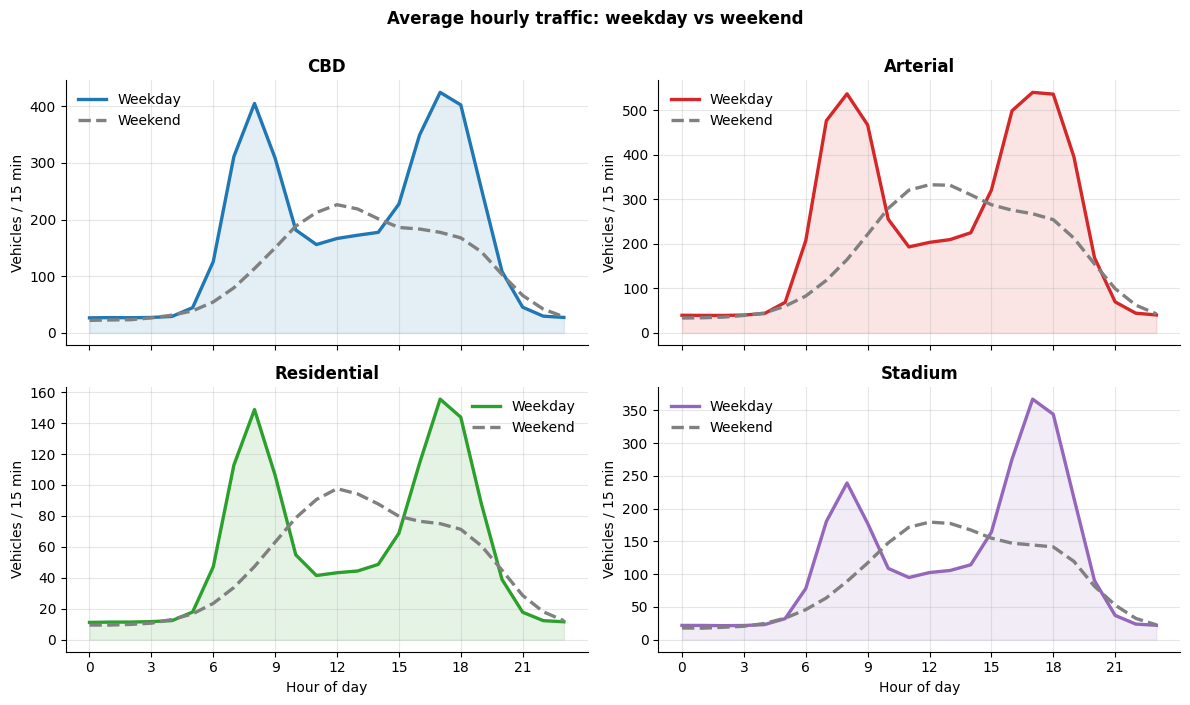

In [4]:
def plot_hourly_profile(df):
    fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
    for ax, site in zip(axes.ravel(), SITES):
        d = df[df["site"] == site]
        prof = d.groupby(["hour", "is_weekend"])["vehicle_count"].mean().unstack()
        ax.plot(prof.index, prof[0], lw=2.4, color=SITE_COLORS[site], label="Weekday")
        ax.plot(prof.index, prof[1], lw=2.4, color="gray", ls="--", label="Weekend")
        ax.fill_between(prof.index, prof[0], alpha=0.12, color=SITE_COLORS[site])
        ax.set_title(site); ax.set_ylabel("Vehicles / 15 min"); ax.legend(frameon=False)
        ax.set_xticks(range(0, 24, 3))
    for ax in axes[1]:
        ax.set_xlabel("Hour of day")
    fig.suptitle("Average hourly traffic: weekday vs weekend", fontweight="bold", y=1.0)
    fig.tight_layout()
    return fig

plot_hourly_profile(df)
plt.show()

## 3. Utilisation heatmap: day x hour

**What it shows:** road utilisation (vehicles / capacity) is highest on weekday rush hours. The single busiest slot is **Wednesday at 5 PM** (about 91% average utilisation across intersections). Saturday and Sunday stay mild all day.

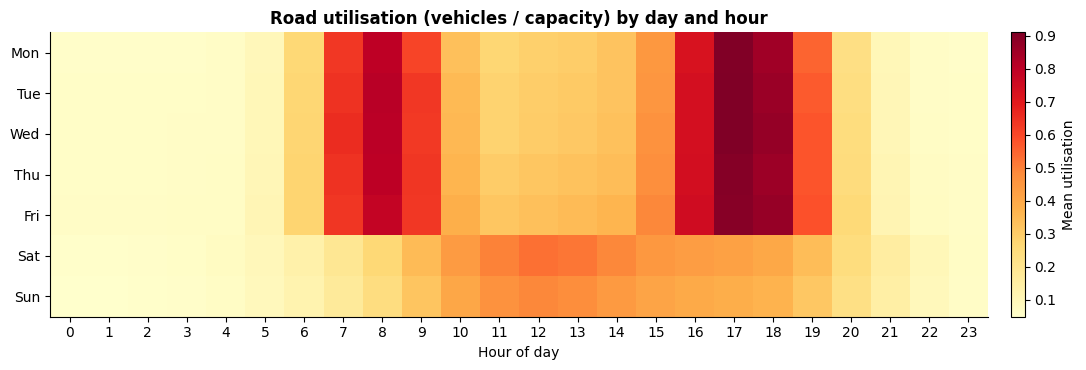

In [5]:
def plot_hour_day_heatmap(df):
    piv = df.pivot_table(index="day_of_week", columns="hour", values="utilisation", aggfunc="mean")
    fig, ax = plt.subplots(figsize=(12, 3.8))
    im = ax.imshow(piv.values, aspect="auto", cmap="YlOrRd")
    ax.set_yticks(range(7)); ax.set_yticklabels(DAY_NAMES)
    ax.set_xticks(range(24)); ax.set_xticklabels(range(24))
    ax.set_xlabel("Hour of day"); ax.grid(False)
    ax.set_title("Road utilisation (vehicles / capacity) by day and hour")
    fig.colorbar(im, ax=ax, label="Mean utilisation", pad=0.02)
    fig.tight_layout()
    return fig

plot_hour_day_heatmap(df)
plt.show()

## 4. One week of raw traffic

**What it shows:** the signal repeats every day, with two spikes on weekdays and a lower, smoother pattern on the shaded weekend days. This regularity is what forecasting models learn from.

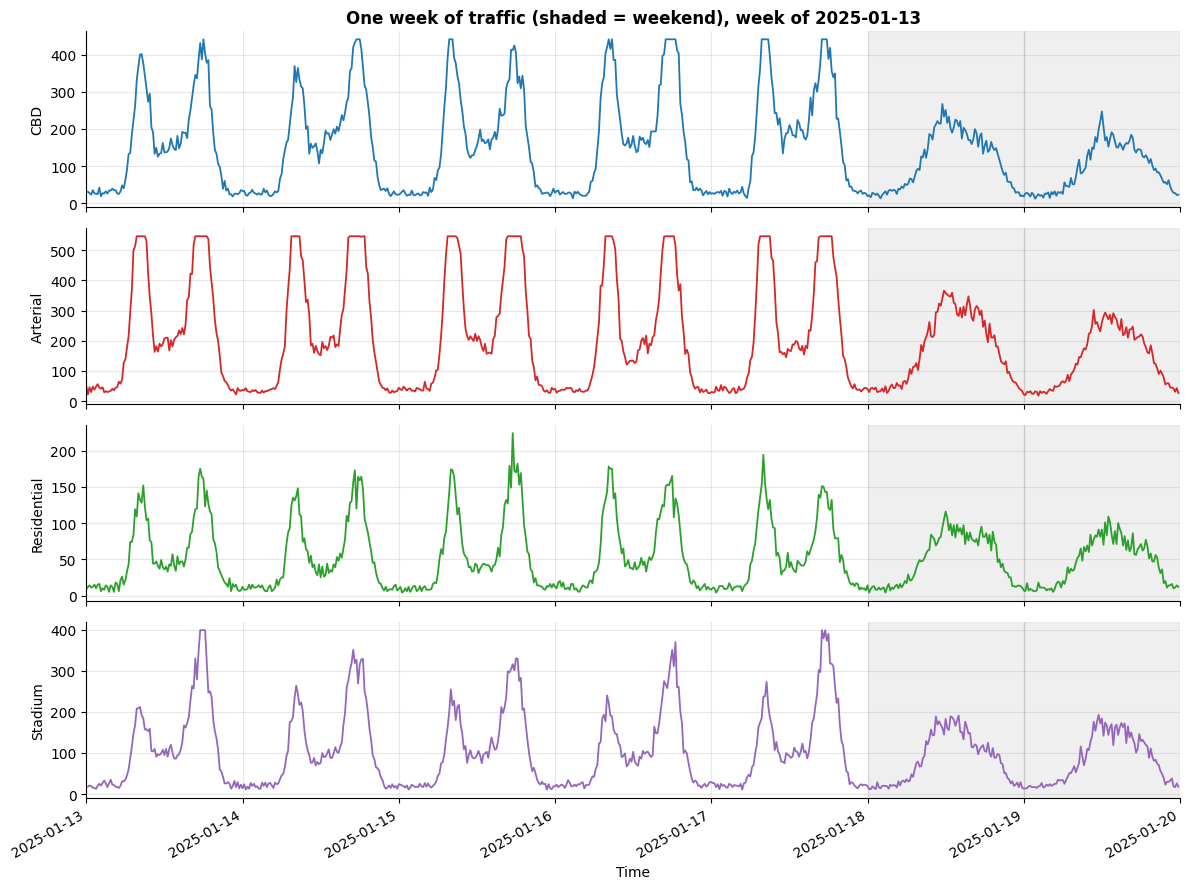

In [6]:
def plot_week_timeseries(df, week_start="2025-01-13"):
    start = pd.Timestamp(week_start)
    w = df[(df["timestamp"] >= start) & (df["timestamp"] < start + pd.Timedelta(days=7))]
    fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
    for ax, site in zip(axes, SITES):
        d = w[w["site"] == site]
        ax.plot(d["timestamp"], d["vehicle_count"], color=SITE_COLORS[site], lw=1.3)
        ax.set_ylabel(site); ax.margins(x=0)
        for day in range(7):
            if (start + pd.Timedelta(days=day)).dayofweek >= 5:
                ax.axvspan(start + pd.Timedelta(days=day), start + pd.Timedelta(days=day + 1),
                           color="gray", alpha=0.12)
    axes[0].set_title(f"One week of traffic (shaded = weekend), week of {week_start}")
    axes[-1].set_xlabel("Time")
    fig.autofmt_xdate()
    fig.tight_layout()
    return fig

plot_week_timeseries(df)
plt.show()

## 5. Speed vs road utilisation

**What it shows:** speed drops as the road fills, and the drop is **non-linear**. Average speed is about 46 km/h below 25% utilisation, about 34 km/h at 50-75%, and only about 16 km/h above 75%. Near capacity, a small increase in volume causes a large slowdown.

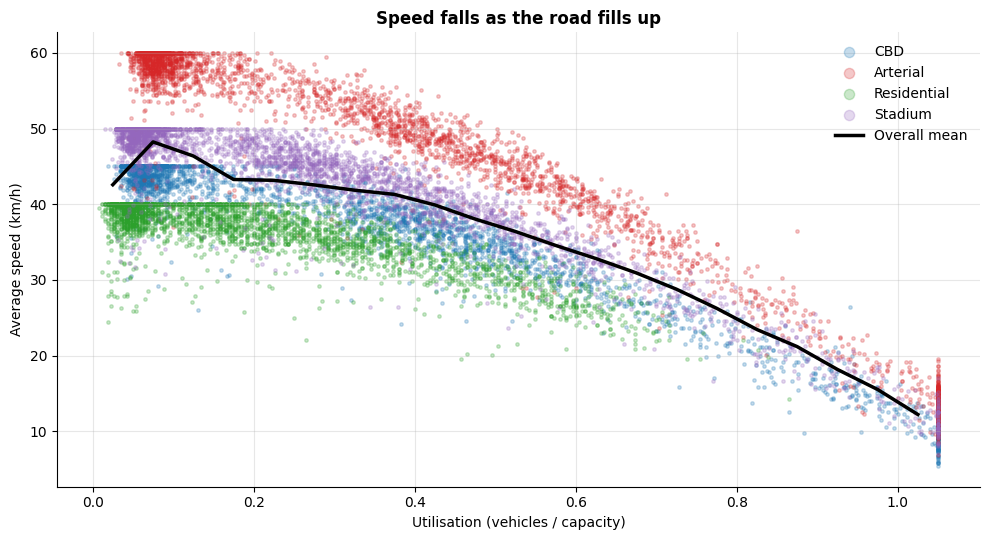

In [7]:
def plot_speed_vs_load(df, sample=12000):
    d = df.sample(min(sample, len(df)), random_state=0)
    fig, ax = plt.subplots(figsize=(10, 5.5))
    for site in SITES:
        s = d[d["site"] == site]
        ax.scatter(s["utilisation"], s["avg_speed_kmh"], s=6, alpha=0.25, color=SITE_COLORS[site], label=site)
    bins = np.linspace(0, 1.05, 22)
    mid = (bins[:-1] + bins[1:]) / 2
    mean = df.groupby(pd.cut(df["utilisation"], bins), observed=True)["avg_speed_kmh"].mean()
    ax.plot(mid[:len(mean)], mean.values, color="black", lw=2.5, label="Overall mean")
    ax.set_xlabel("Utilisation (vehicles / capacity)"); ax.set_ylabel("Average speed (km/h)")
    ax.set_title("Speed falls as the road fills up")
    ax.legend(markerscale=3, frameon=False)
    fig.tight_layout()
    return fig

plot_speed_vs_load(df)
plt.show()

## 6. Rain effect

**What it shows:** heavier rain lowers speed (about 40 km/h when dry to about 37 km/h in heavy rain) and increases waiting time (about 21 s to 25 s). The effect is real but **modest**, and rain is rare (most intervals are dry), so its overall correlation with speed is weak.

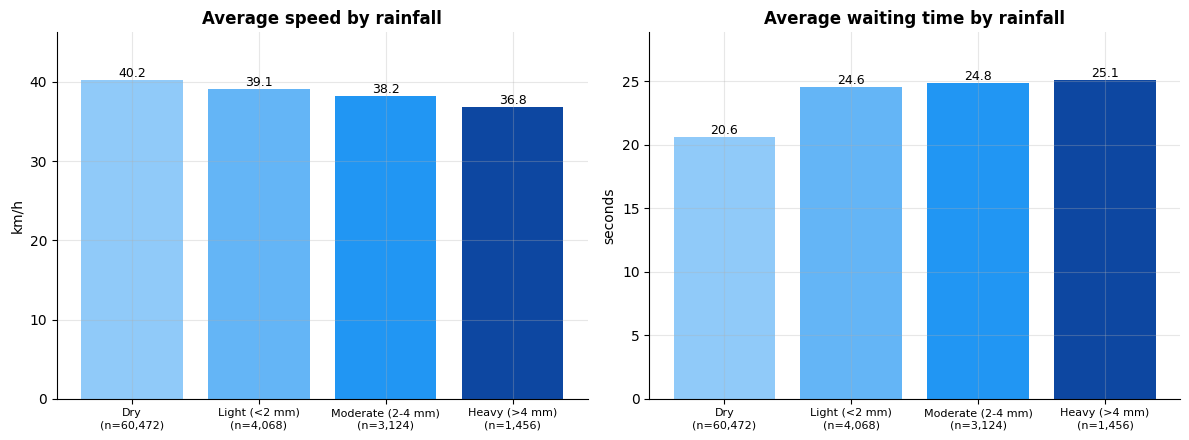

In [8]:
def plot_weather_effect(df):
    bins = [-0.01, 0.0, 2.0, 4.0, np.inf]
    labels = ["Dry", "Light (<2 mm)", "Moderate (2-4 mm)", "Heavy (>4 mm)"]
    d = df.assign(rain=pd.cut(df["rain_mm_15min"], bins, labels=labels))
    g = d.groupby("rain", observed=True)[["avg_speed_kmh", "avg_waiting_time_sec"]].mean()
    n = d["rain"].value_counts().reindex(g.index)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
    colors = ["#90caf9", "#64b5f6", "#2196f3", "#0d47a1"][:len(g)]
    for a, col, title, unit in zip(ax, g.columns, ["Average speed", "Average waiting time"], ["km/h", "seconds"]):
        bars = a.bar(range(len(g)), g[col].values, color=colors)
        a.set_xticks(range(len(g))); a.set_xticklabels([f"{i}\n(n={n[i]:,})" for i in g.index], fontsize=8)
        a.set_title(f"{title} by rainfall"); a.set_ylabel(unit)
        for b, v in zip(bars, g[col].values):
            a.text(b.get_x() + b.get_width() / 2, v, f"{v:.1f}", ha="center", va="bottom", fontsize=9)
        a.set_ylim(0, g[col].max() * 1.15)
    fig.tight_layout()
    return fig

plot_weather_effect(df)
plt.show()

## 7. Incident impact

**What it shows:** incidents hurt far more than rain. Average speed falls from about 40 to 32 km/h, **waiting time nearly doubles** (about 21 s to 39 s), and queues grow from about 16 to 21 vehicles.

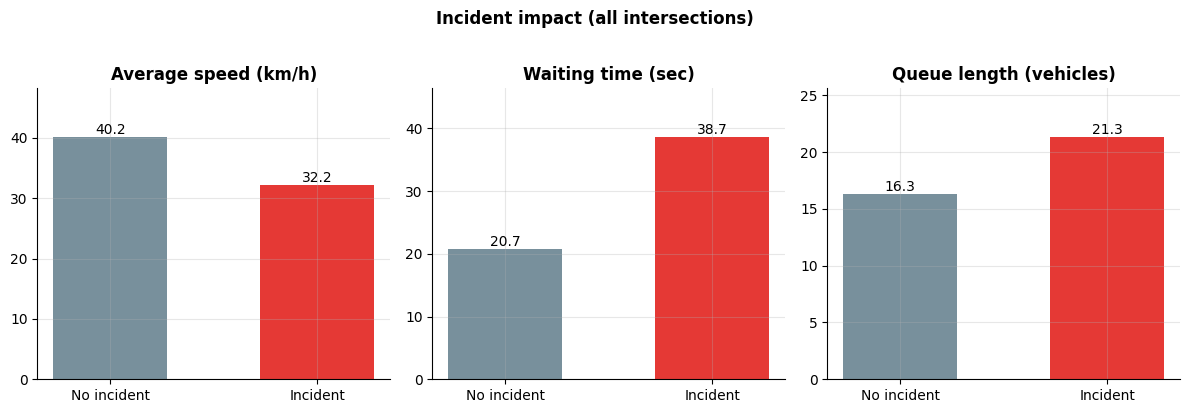

In [9]:
def plot_incident_impact(df):
    cols = [("avg_speed_kmh", "Average speed (km/h)"), ("avg_waiting_time_sec", "Waiting time (sec)"),
            ("queue_length_veh", "Queue length (vehicles)")]
    g = df.groupby("incident_flag")[[c for c, _ in cols]].mean()
    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    for a, (c, title) in zip(ax, cols):
        bars = a.bar(["No incident", "Incident"], g[c].values, color=["#78909c", "#e53935"], width=0.55)
        for b, v in zip(bars, g[c].values):
            a.text(b.get_x() + b.get_width() / 2, v, f"{v:.1f}", ha="center", va="bottom")
        a.set_title(title); a.set_ylim(0, g[c].max() * 1.2)
    fig.suptitle("Incident impact (all intersections)", fontweight="bold", y=1.02)
    fig.tight_layout()
    return fig

plot_incident_impact(df)
plt.show()

## 8. Stadium events

**What it shows:** during an event, evening traffic at the stadium intersection is clearly higher. For example, about **+40% at 4 PM** and about +38% at 7 PM, so the evening peak starts earlier and lasts longer. At 5 PM the gain is small because regular commuters already fill the road.

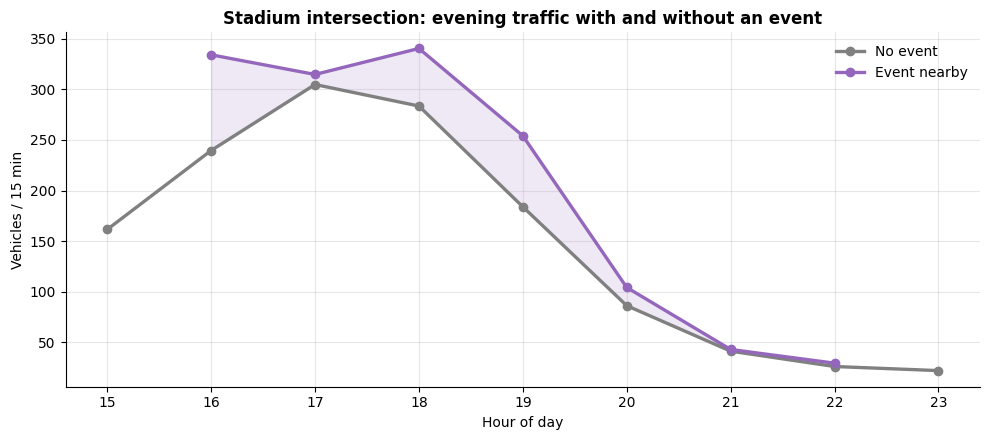

In [10]:
def plot_stadium_event(df):
    s = df[df["site"] == "Stadium"]
    hours = range(15, 24)
    prof = s[s["hour"].isin(hours)].groupby(["hour", "event_nearby"])["vehicle_count"].mean().unstack()
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.plot(prof.index, prof[0], marker="o", lw=2.4, color="gray", label="No event")
    ax.plot(prof.index, prof[1], marker="o", lw=2.4, color="#9467bd", label="Event nearby")
    ax.fill_between(prof.index, prof[0], prof[1], where=prof[1] > prof[0], color="#9467bd", alpha=0.15)
    ax.set_xlabel("Hour of day"); ax.set_ylabel("Vehicles / 15 min")
    ax.set_title("Stadium intersection: evening traffic with and without an event")
    ax.legend(frameon=False)
    fig.tight_layout()
    return fig

plot_stadium_event(df)
plt.show()

## 9. Correlation heatmap

**What it shows:**
- Vehicle count correlates strongly with **waiting time (0.90)** and **queue length (0.90)**, and negatively with **speed (-0.70)**.
- The previous interval's count correlates at **0.98**, so recent traffic is a very strong predictor.
- Weather and incident flags have weak *linear* correlation with volume. Their influence appears through speed and delay, which is where non-linear models can help.

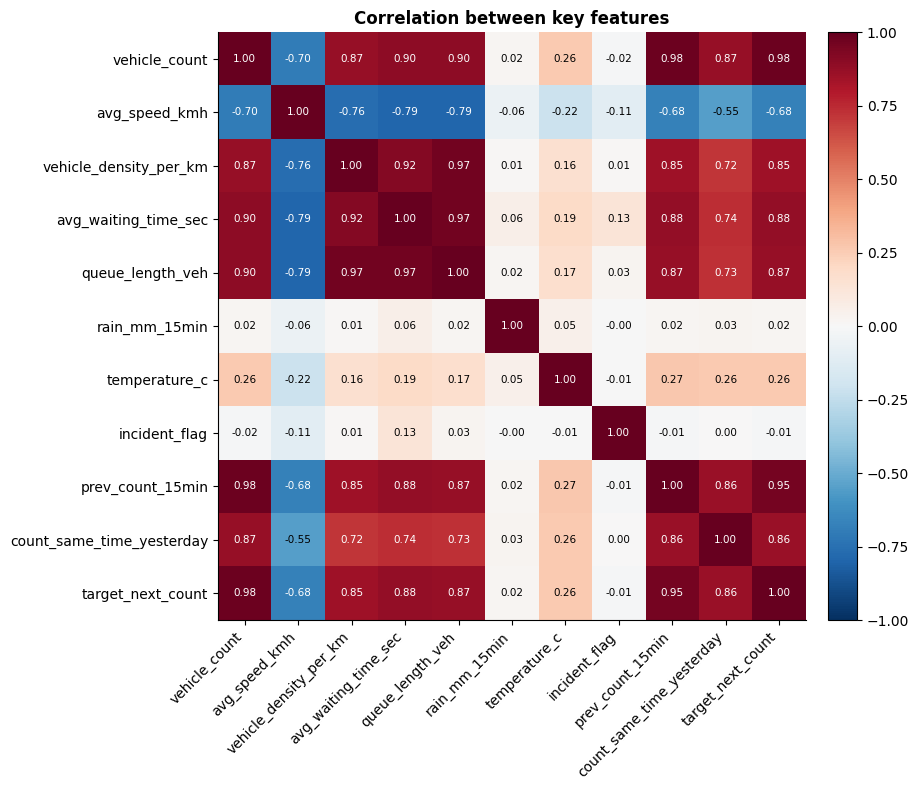

In [11]:
def plot_correlation(df):
    cols = ["vehicle_count", "avg_speed_kmh", "vehicle_density_per_km", "avg_waiting_time_sec",
            "queue_length_veh", "rain_mm_15min", "temperature_c", "incident_flag", "prev_count_15min",
            "count_same_time_yesterday", "target_next_count"]
    c = df[cols].corr()
    fig, ax = plt.subplots(figsize=(9.5, 8))
    im = ax.imshow(c.values, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=45, ha="right")
    ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols); ax.grid(False)
    for i in range(len(cols)):
        for j in range(len(cols)):
            ax.text(j, i, f"{c.values[i, j]:.2f}", ha="center", va="center", fontsize=7.5,
                    color="white" if abs(c.values[i, j]) > 0.6 else "black")
    ax.set_title("Correlation between key features")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
    fig.tight_layout()
    return fig

plot_correlation(df)
plt.show()

## 10. Autocorrelation

**What it shows:** traffic is extremely persistent (autocorrelation 0.98 at one step) and strongly **daily-periodic**: it is negatively correlated 12 hours apart (-0.43) and comes back to 0.83 at exactly 24 hours. This is why "same time yesterday" and recent-lag features are so valuable.

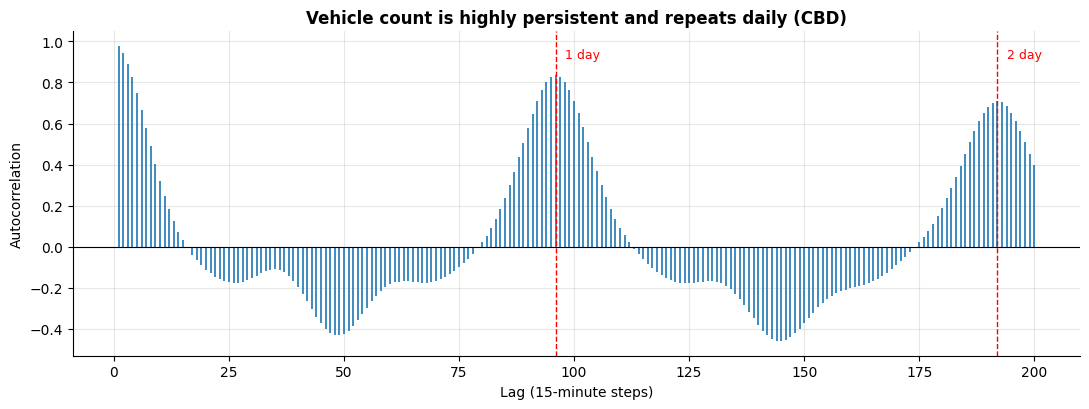

In [12]:
def plot_autocorrelation(df, max_lag=2 * 96 + 8):
    s = df[df["site"] == "CBD"].set_index("timestamp")["vehicle_count"]
    lags = np.arange(1, max_lag + 1)
    acf = np.array([s.autocorr(int(l)) for l in lags])
    fig, ax = plt.subplots(figsize=(11, 4.2))
    ax.vlines(lags, 0, acf, color="#1f77b4", lw=1.2)
    ax.axhline(0, color="black", lw=0.8)
    for day in (1, 2):
        ax.axvline(day * 96, color="red", ls="--", lw=1)
        ax.text(day * 96 + 2, 0.92, f"{day} day", color="red", fontsize=9)
    ax.set_xlabel("Lag (15-minute steps)"); ax.set_ylabel("Autocorrelation")
    ax.set_title("Vehicle count is highly persistent and repeats daily (CBD)")
    fig.tight_layout()
    return fig

plot_autocorrelation(df)
plt.show()

## 11. Congestion by hour of day

**What it shows:** congestion is concentrated in the rush hours. *High* + *Severe* make up about **51% of intervals at 8 AM** and about **64% at 5 PM**, compared with about 8% at noon and essentially 0% at 3 AM.

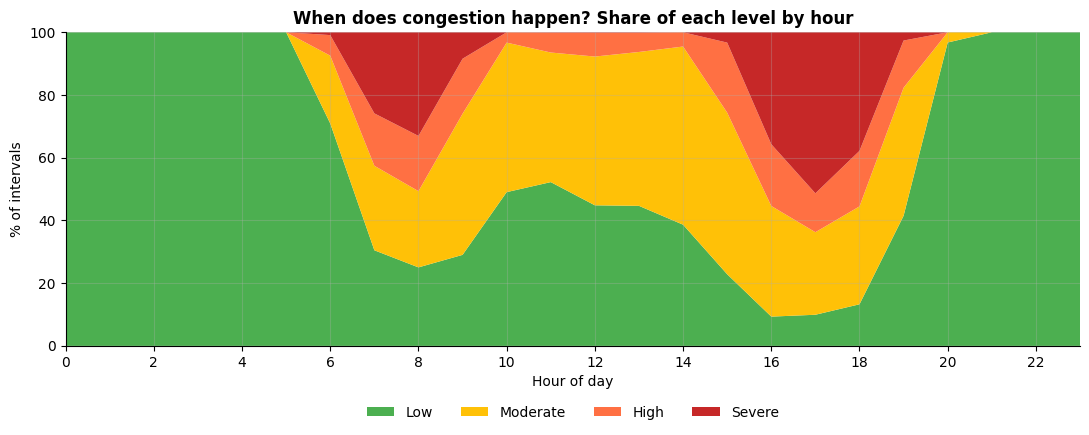

In [13]:
def plot_congestion_by_hour(df):
    d = df.dropna(subset=["target_congestion"])
    ct = pd.crosstab(d["hour"], d["target_congestion"], normalize="index").reindex(columns=LEVELS) * 100
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.stackplot(ct.index, [ct[l] for l in LEVELS], labels=LEVELS, colors=[LEVEL_COLORS[l] for l in LEVELS])
    ax.set_xlim(0, 23); ax.set_ylim(0, 100); ax.set_xticks(range(0, 24, 2))
    ax.set_xlabel("Hour of day"); ax.set_ylabel("% of intervals")
    ax.set_title("When does congestion happen? Share of each level by hour")
    ax.legend(loc="upper center", ncol=4, bbox_to_anchor=(0.5, -0.15), frameon=False)
    fig.tight_layout()
    return fig

plot_congestion_by_hour(df)
plt.show()

## 12. Daily totals over time

**What it shows:** a steady **weekly cycle** with no strong long-term trend. Weekend days carry roughly 72% of the weekday volume on average. The thick lines (7-day average) are flat, so the weekly pattern, not the season, drives most of the variation.

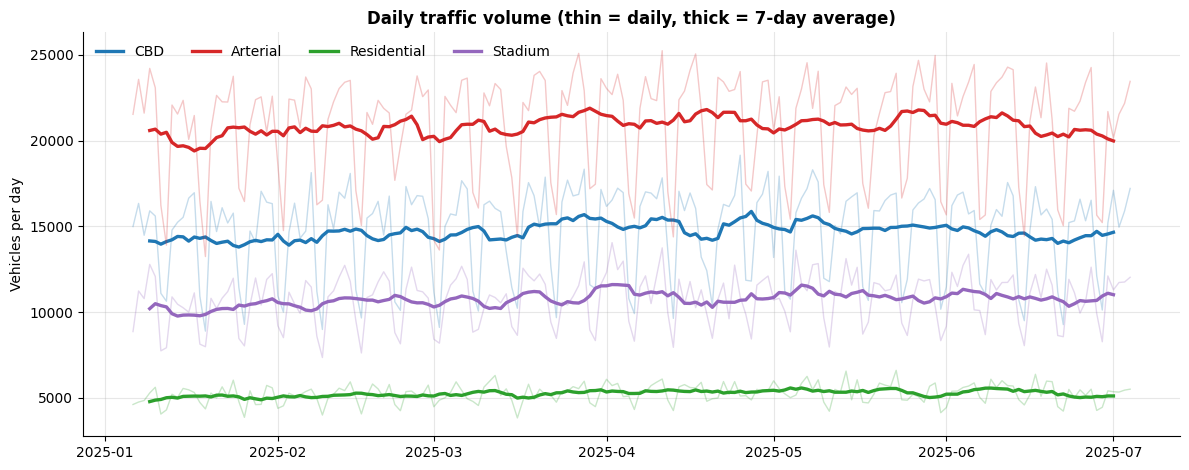

In [14]:
def plot_daily_totals(df):
    daily = df.groupby(["date", "site"])["vehicle_count"].sum().unstack()[SITES]
    daily.index = pd.to_datetime(daily.index)
    fig, ax = plt.subplots(figsize=(12, 4.8))
    for site in SITES:
        ax.plot(daily.index, daily[site], color=SITE_COLORS[site], alpha=0.25, lw=1)
        ax.plot(daily.index, daily[site].rolling(7, center=True).mean(), color=SITE_COLORS[site], lw=2.4, label=site)
    ax.set_ylabel("Vehicles per day"); ax.set_title("Daily traffic volume (thin = daily, thick = 7-day average)")
    ax.legend(ncol=4, frameon=False)
    fig.tight_layout()
    return fig

plot_daily_totals(df)
plt.show()

## Key takeaways for modelling

1. **Time of day and weekday/weekend** are the strongest drivers: include `hour`, `day_of_week`, `is_weekend`.
2. **Lag features** (previous 15 min, same time yesterday) carry most of the predictive signal.
3. **Class imbalance** in congestion levels: evaluate with macro-F1, not just accuracy.
4. **Non-linear speed collapse near capacity** and **incident/event effects** suggest tree-based models over linear ones.
5. Keep a **chronological** train/test split and compare with the persistence baseline.